# CardioIA - Fase 2 | Parte 2
## Classificador de risco a partir de frases de sintomas

Aqui a ideia é simular uma triagem automática: o paciente descreve o que está sentindo e o modelo classifica a frase como **alto risco** ou **baixo risco**.

Etapas:
1. Carregar a base `frases_risco.csv` (montada pelo grupo, com 160 frases rotuladas)
2. Transformar o texto em números com TF-IDF
3. Treinar e comparar dois modelos (Regressão Logística e Árvore de Decisão)
4. Avaliar acurácia, matriz de confusão e erros
5. Testar com frases novas e discutir vieses e distorções

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

### 1. Explorando a base

In [2]:
df = pd.read_csv("frases_risco.csv")
print(df.shape)
df.sample(8, random_state=1)

(160, 2)


,frase,situacao
29,tive uma azia depois do almoço,baixo risco
42,sinto o olho cansado depois de usar o celular,baixo risco
14,sinto o pescoço tenso depois de trabalhar no c...,baixo risco
91,acordei sem conseguir respirar direito,alto risco
81,sinto o coração bater forte quando estou nervo...,baixo risco
19,estou com o pulso muito acelerado e suor frio,alto risco
44,minha pressão não baixa nem com o remédio e es...,alto risco
11,estou com espinhas no rosto,baixo risco


In [3]:
df["situacao"].value_counts()

situacao
alto risco     80
baixo risco    80
Name: count, dtype: int64

In [4]:
df["qtd_palavras"] = df["frase"].str.split().str.len()
df.groupby("situacao")["qtd_palavras"].describe()

,count,mean,std,min,25%,50%,75%,max
situacao,,,,,,,,
alto risco,80.0,9.7500,2.330318,5.0,8.0,9.5,11.0,16.0
baixo risco,80.0,8.4125,2.347602,3.0,7.0,8.0,10.0,14.0


A base está balanceada (80 frases de cada classe), então a acurácia não fica "inflada" por uma classe dominante.

Um detalhe que já aparece aqui: as frases de alto risco são um pouco mais longas que as de baixo risco. Isso pode virar um atalho para o modelo, e voltamos a esse ponto na análise de vieses.

### 2. Separando treino e teste

In [5]:
X = df["frase"]
y = df["situacao"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Treino:", len(X_treino), "| Teste:", len(X_teste))
print(y_teste.value_counts())

Treino: 120 | Teste: 40
situacao
baixo risco    20
alto risco     20
Name: count, dtype: int64


### 3. TF-IDF
O TF-IDF dá um peso para cada palavra: palavras frequentes na frase mas raras na base inteira ganham peso maior. Usamos também bigramas (pares de palavras), porque expressões como "dor no peito" ou "falta de ar" dizem mais que as palavras soltas.

Não removemos stopwords de propósito: palavras como "não", "leve" e "pouco" mudam bastante o sentido de uma frase de sintoma.

In [6]:
tfidf = TfidfVectorizer(strip_accents="unicode", lowercase=True, ngram_range=(1, 2))
X_treino_vet = tfidf.fit_transform(X_treino)
X_teste_vet = tfidf.transform(X_teste)

print("Tamanho do vocabulário:", len(tfidf.vocabulary_))
print("Formato da matriz de treino:", X_treino_vet.shape)

Tamanho do vocabulário: 942
Formato da matriz de treino: (120, 942)


In [7]:
exemplo = tfidf.transform(["sinto dor no peito e falta de ar"])
termos = tfidf.get_feature_names_out()
pesos = pd.Series(exemplo.toarray()[0], index=termos)
pesos[pesos > 0].sort_values(ascending=False)

peito falta    0.471844
falta          0.314205
falta de       0.314205
de ar          0.314205
sinto dor      0.306159
ar             0.279557
dor no         0.250109
no peito       0.234662
peito          0.218397
no             0.194827
sinto          0.194827
dor            0.192544
de             0.176061
dtype: float64

### 4. Treinando os modelos

In [8]:
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42),
}

previsoes = {}
for nome, modelo in modelos.items():
    modelo.fit(X_treino_vet, y_treino)
    previsoes[nome] = modelo.predict(X_teste_vet)
    print(f"{nome}: acurácia = {accuracy_score(y_teste, previsoes[nome]):.2%}")

Regressão Logística: acurácia = 87.50%
Árvore de Decisão: acurácia = 80.00%


In [9]:
for nome, pred in previsoes.items():
    print("=" * 55)
    print(nome)
    print(classification_report(y_teste, pred, digits=3))

Regressão Logística
              precision    recall  f1-score   support

  alto risco      0.895     0.850     0.872        20
 baixo risco      0.857     0.900     0.878        20

    accuracy                          0.875        40
   macro avg      0.876     0.875     0.875        40
weighted avg      0.876     0.875     0.875        40

Árvore de Decisão
              precision    recall  f1-score   support

  alto risco      0.833     0.750     0.789        20
 baixo risco      0.773     0.850     0.810        20

    accuracy                          0.800        40
   macro avg      0.803     0.800     0.799        40
weighted avg      0.803     0.800     0.799        40



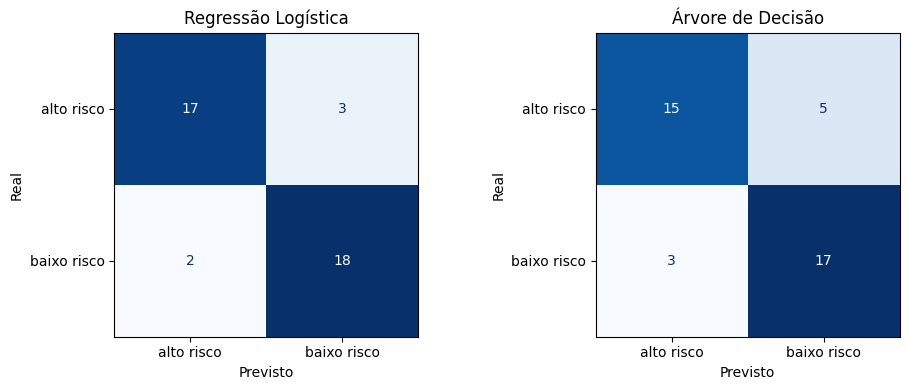

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (nome, pred) in zip(axes, previsoes.items()):
    cm = confusion_matrix(y_teste, pred, labels=["alto risco", "baixo risco"])
    ConfusionMatrixDisplay(cm, display_labels=["alto risco", "baixo risco"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nome)
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

Na triagem, o erro mais perigoso é o **falso negativo**: uma frase de alto risco classificada como baixo risco. Por isso, além da acurácia, olhamos com atenção o *recall* da classe "alto risco" e a célula de cima à direita da matriz.

### 5. Validação cruzada
Com só 40 frases no teste, uma única divisão pode dar sorte ou azar. A validação cruzada com 5 partes dá uma ideia mais estável do desempenho.

In [11]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nome, modelo in modelos.items():
    pipe = make_pipeline(TfidfVectorizer(strip_accents="unicode", ngram_range=(1, 2)), modelo)
    notas = cross_val_score(pipe, X, y, cv=kfold, scoring="accuracy")
    print(f"{nome}: {notas.round(3)} -> média {notas.mean():.2%} (+/- {notas.std():.2%})")

Regressão Logística: [0.969 0.844 0.719 0.969 0.906] -> média 88.12% (+/- 9.35%)
Árvore de Decisão: [0.688 0.75  0.719 0.812 0.812] -> média 75.62% (+/- 5.00%)


### 6. Erros no conjunto de teste

In [12]:
erros = pd.DataFrame({
    "frase": X_teste,
    "real": y_teste,
    "logistica": previsoes["Regressão Logística"],
    "arvore": previsoes["Árvore de Decisão"],
})
erros[(erros["real"] != erros["logistica"]) | (erros["real"] != erros["arvore"])]

,frase,real,logistica,arvore
127,o lado esquerdo do rosto ficou dormente de rep...,alto risco,alto risco,baixo risco
148,tenho angina e a dor não passou com o remédio ...,alto risco,baixo risco,alto risco
71,tenho um leve inchaço nos pés depois de um dia...,baixo risco,baixo risco,alto risco
141,desmaiei enquanto subia a escada,alto risco,alto risco,baixo risco
123,estou com a pele ressecada,baixo risco,alto risco,baixo risco
12,estou com dor de cabeça por ficar muito tempo ...,baixo risco,baixo risco,alto risco
150,tive uma dor de cabeça súbita muito forte e a ...,alto risco,baixo risco,baixo risco
58,desmaiei hoje de manhã sem motivo aparente,alto risco,baixo risco,baixo risco
38,meu tornozelo inchou e agora estou com dor ao ...,alto risco,alto risco,baixo risco
114,estou espirrando muito por causa da poeira,baixo risco,baixo risco,alto risco


### 7. O que o modelo aprendeu
Na Regressão Logística dá para ver o peso de cada termo. Valores positivos puxam para uma classe e negativos para a outra.

Classe positiva do modelo: baixo risco


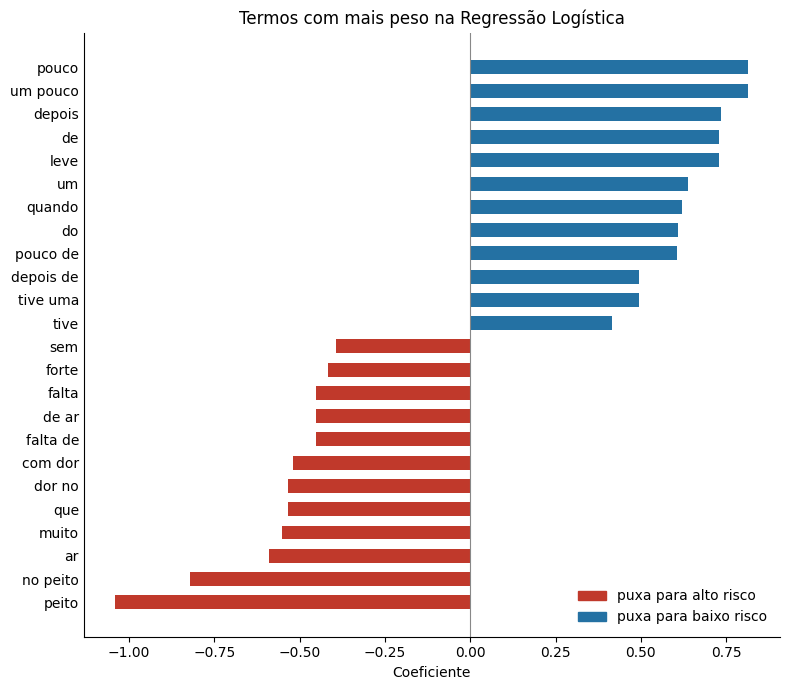

In [13]:
logistica = modelos["Regressão Logística"]
print("Classe positiva do modelo:", logistica.classes_[1])

coefs = pd.Series(logistica.coef_[0], index=tfidf.get_feature_names_out()).sort_values()
top = pd.concat([coefs.head(12), coefs.tail(12)])

cores = ["#c0392b" if v < 0 else "#2471a3" for v in top.values]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top.index, top.values, color=cores, height=0.6)
ax.axvline(0, color="#888888", linewidth=0.8)
ax.set_title("Termos com mais peso na Regressão Logística")
ax.set_xlabel("Coeficiente")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.legend(handles=[
    plt.Rectangle((0, 0), 1, 1, color="#c0392b", label="puxa para alto risco"),
    plt.Rectangle((0, 0), 1, 1, color="#2471a3", label="puxa para baixo risco"),
], loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

In [14]:
arvore = modelos["Árvore de Decisão"]
importancia = pd.Series(arvore.feature_importances_, index=tfidf.get_feature_names_out())
print("Profundidade da árvore:", arvore.get_depth())
importancia[importancia > 0].sort_values(ascending=False).head(10)

Profundidade da árvore: 12


peito            0.198036
ar               0.107884
que              0.081068
muito            0.074357
falar            0.067557
de um            0.055684
coracao          0.052033
nao              0.048729
dor              0.047727
estao ficando    0.032716
dtype: float64

### 8. Testando com frases novas
Frases escritas pelo grupo que **não estão** na base, incluindo alguns casos difíceis de propósito (negação, palavras de risco em contexto leve, sinônimos que o modelo nunca viu).

In [15]:
novas = [
    "estou com muita dor no peito e suando frio",
    "sinto um leve cansaço depois de caminhar",
    "minha mão esquerda ficou dormente e a fala ficou esquisita",
    "não sinto dor no peito nem falta de ar",
    "tive uma dor leve no peito depois de tossir muito",
    "estou com taquicardia e sensação de desmaio",
    "estou com dispneia intensa",
    "meu filho caiu e ralou o joelho",
    "estou com dor de cabeça e dor nas costas",
    "sinto o peito apertado quando fico ansioso",
]

vet_novas = tfidf.transform(novas)
idx_alto = list(logistica.classes_).index("alto risco")

resultado_novas = pd.DataFrame({
    "frase": novas,
    "logistica": logistica.predict(vet_novas),
    "prob_alto_risco": logistica.predict_proba(vet_novas)[:, idx_alto].round(2),
    "arvore": arvore.predict(vet_novas),
})
pd.set_option("display.max_colwidth", 70)
resultado_novas

,frase,logistica,prob_alto_risco,arvore
0,estou com muita dor no peito e suando frio,alto risco,0.72,alto risco
1,sinto um leve cansaço depois de caminhar,baixo risco,0.26,baixo risco
2,minha mão esquerda ficou dormente e a fala ficou esquisita,alto risco,0.58,baixo risco
3,não sinto dor no peito nem falta de ar,alto risco,0.74,alto risco
4,tive uma dor leve no peito depois de tossir muito,baixo risco,0.40,alto risco
5,estou com taquicardia e sensação de desmaio,alto risco,0.52,baixo risco
6,estou com dispneia intensa,alto risco,0.57,baixo risco
7,meu filho caiu e ralou o joelho,alto risco,0.55,baixo risco
8,estou com dor de cabeça e dor nas costas,baixo risco,0.43,alto risco
9,sinto o peito apertado quando fico ansioso,alto risco,0.54,alto risco


### 9. Análise de vieses e distorções

**Desempenho geral.** A Regressão Logística foi melhor nos dois testes: 87,5% de acurácia no conjunto de teste e cerca de 88% de média na validação cruzada, contra 80% e 76% da Árvore de Decisão. A árvore cresceu até profundidade 12 para decorar as 120 frases de treino, o que é sinal de *overfitting*: com tão poucos exemplos, ela cria regras muito específicas que não generalizam.

**Falsos negativos.** A logística deixou passar 3 frases de alto risco como baixo risco e a árvore deixou 5. Entre elas está "desmaiei hoje de manhã sem motivo aparente", um caso claramente grave. Numa triagem real esse é o erro que mais importa, porque o paciente grave iria para o fim da fila.

**O modelo aprende o "jeito de escrever", não só os sintomas.** O gráfico de pesos mostra que palavras como "pouco", "leve", "depois", "tive" e até "de" e "um" puxam para baixo risco, enquanto "muito", "forte" e "que" puxam para alto risco. Isso reflete como **nós** escrevemos a base: as frases leves quase sempre têm "um pouco" ou "leve", e as graves têm "muito" e "forte". O modelo pegou esse atalho. As frases de alto risco também ficaram um pouco mais longas, em média 9,8 contra 8,4 palavras.

**Negação.** "não sinto dor no peito nem falta de ar" foi classificada como **alto risco** com 74% de probabilidade. O TF-IDF trata as palavras quase de forma independente, então "dor no peito" e "falta de ar" pesam mais que o "não".

**Vocabulário desconhecido.** "estou com dispneia intensa" e "meu filho caiu e ralou o joelho" ficaram perto de 55%, praticamente no chute. Quando o modelo não conhece as palavras ("dispneia", "taquicardia", "ralou"), ele não tem informação e a decisão fica na fronteira. Termos médicos corretos, que um paciente mais instruído usaria, acabam sendo mal avaliados porque a base foi escrita em linguagem popular.

**Palavra "peito" domina.** "sinto o peito apertado quando fico ansioso" vira alto risco só pela palavra "peito", enquanto "tive uma dor leve no peito depois de tossir muito" cai para baixo risco por causa de "leve" e "depois". Parte disso faz sentido clinicamente, mas mostra que poucas palavras decidem o resultado.

**Viés de origem dos dados.** A base tem só 160 frases, todas escritas pelo mesmo grupo, em português informal e sem variações regionais, erros de digitação ou relatos longos. Pacientes reais escrevem de formas muito mais variadas. Também não há informação de idade, sexo ou histórico, que mudam bastante o risco real de uma mesma queixa.

### Conclusão
Mesmo com uma base pequena, o pipeline TF-IDF + Regressão Logística chegou perto de 88% de acurácia e mostra bem a lógica de uma triagem automatizada. Por outro lado, os testes deixam claro que o modelo é frágil: erra com negação, com termos técnicos e se apoia em palavras de intensidade em vez do sintoma em si.

Por isso um sistema assim só pode ser usado como **apoio** à triagem, sempre com revisão de um profissional de saúde. Para evoluir, os próximos passos seriam aumentar e diversificar a base (de preferência com relatos reais anonimizados e rótulos revisados por médicos), tratar negações, ajustar o limiar de decisão para priorizar o recall de alto risco e testar modelos que entendem contexto.